<a href="https://colab.research.google.com/github/Sandesh171144/transfer_learning/blob/main/transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/


cp: cannot stat 'kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d salader/dogs-vs-cats

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("salader/dogsvscats")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dogsvscats' dataset.
Path to dataset files: /kaggle/input/dogsvscats


In [ ]:
dataset = path

'/kaggle/input/dogsvscats'

In [2]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
import pickle
from tensorflow.keras.models import Sequential
from keras.applications.vgg16 import VGG16


In [3]:
conv_base = VGG16(weights='imagenet',include_top=False, input_shape=(150, 150, 3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(5,activation ='softmax'))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,813,381 (64.14 MB)

 Trainable params: 16,813,381 (64.14 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
conv_base.trainable = False

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,813,381 (64.14 MB)

 Trainable params: 2,098,693 (8.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [9]:
path = "/content/drive/MyDrive/Focus/ANN and CNN/flower_images"

In [10]:

from jax import image
# generators
train_ds = keras.utils.image_dataset_from_directory(
    path,
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (150,150),
    validation_split = 0.2,
    subset = 'training',
    seed = 123
)
validation_ds = keras.utils.image_dataset_from_directory(
    path,
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (150,150),
    validation_split = 0.2,
    subset = 'validation',
    seed = 123
)

Found 4999 files belonging to 5 classes.
Using 4000 files for training.
Found 4999 files belonging to 5 classes.
Using 999 files for validation.


In [11]:
# Normalize
def process(image,label):
  image = tf.cast(image/255., tf.float32)
  return image,label

In [12]:
train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history = model.fit(train_ds,epochs=10,validation_data =validation_ds)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 489s 4s/step - accuracy: 0.7005 - loss: 0.8786 - val_accuracy: 0.7948 - val_loss: 0.5994
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 23s 182ms/step - accuracy: 0.8950 - loss: 0.3346 - val_accuracy: 0.8348 - val_loss: 0.4793
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 23s 182ms/step - accuracy: 0.9440 - loss: 0.1925 - val_accuracy: 0.8669 - val_loss: 0.4294
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 23s 182ms/step - accuracy: 0.9770 - loss: 0.1066 - val_accuracy: 0.8849 - val_loss: 0.3710
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 172ms/step - accuracy: 0.9895 - loss: 0.0581 - val_accuracy: 0.9089 - val_loss: 0.3431
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 23s 183ms/step - accuracy: 0.9925 - loss: 0.0416 - val_accuracy: 0.9159 - val_loss: 0.3549
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 177ms/step - accuracy: 0.9952 - loss: 0.0325 - val_accuracy: 0.8819 - val_loss: 0.4241
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 23s 181ms/step - accuracy: 0.9948 - loss: 0.0

In [ ]:
import matplotlib.pyplot as plt

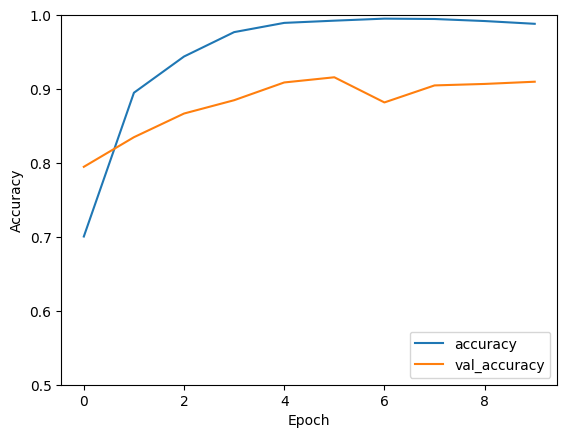

In [ ]:
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5,1])
plt.legend(loc='lower right')

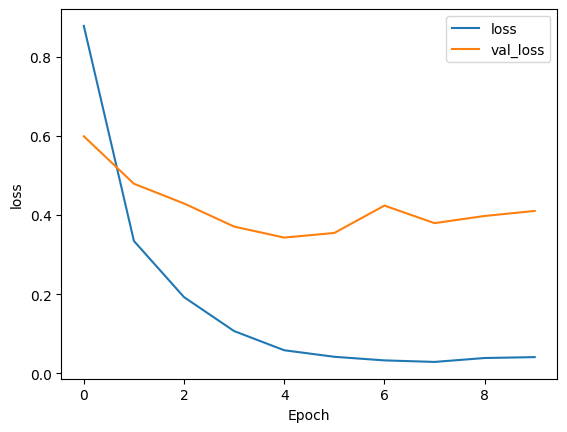

In [ ]:
plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.legend()

In [5]:
conv_base.trainable = True

In [6]:
set_trainable = False

for layer in conv_base.layers:
  if layer.name =='block5_conv1':
    set_trainable=True
  if set_trainable:
    layer.trainable = True
  else:
    layer.trainable = False
for layer in conv_base.layers:
  print(layer.name,layer.trainable)


input_layer False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [7]:
model = Sequential()
model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(5,activation ='softmax'))

In [8]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [13]:
history = model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 801s 6s/step - accuracy: 0.2015 - loss: 1.8426 - val_accuracy: 0.1782 - val_loss: 1.6099
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 23s 184ms/step - accuracy: 0.2052 - loss: 1.6096 - val_accuracy: 0.1782 - val_loss: 1.6103
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 181ms/step - accuracy: 0.2052 - loss: 1.6095 - val_accuracy: 0.1782 - val_loss: 1.6106
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 176ms/step - accuracy: 0.2052 - loss: 1.6096 - val_accuracy: 0.1782 - val_loss: 1.6104
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 23s 185ms/step - accuracy: 0.2052 - loss: 1.6095 - val_accuracy: 0.1782 - val_loss: 1.6106
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 178ms/step - accuracy: 0.2052 - loss: 1.6096 - val_accuracy: 0.1782 - val_loss: 1.6105
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 23s 186ms/step - accuracy: 0.2052 - loss: 1.6095 - val_accuracy: 0.1782 - val_loss: 1.6106
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 185ms/step - accuracy: 0.2052 - loss: 1.6